In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [ ]:
# Load data
df = pd.read_csv("student-mat.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
#Prepare data
# Convert final grade to percentage
df["G3_percent"] = (df["G3"] / 20) * 100

# Create binary target 1 = Pass, 0 = Fail
df["target"] = (df["G3_percent"] >=50).astype(int)

df[["G3", "G3_percent", "target"]].head()

,G3,G3_percent,target
0,6,30.0,0
1,6,30.0,0
2,10,50.0,1
3,15,75.0,1
4,10,50.0,1


In [ ]:
# Drop original G3 (we don't want leakage)
df = df.drop(columns=["G3"])

# Encode categorical columns (separate encoder per column)
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
#Added a new feature "Student Understanding"
# NOTE: The UCI dataset does NOT contain this feature.
# 'understanding' is simulated from G1 for training only.
# In the deployed app, this value is provided directly by the student.


df["stud_understanding"] = pd.cut(
    df["G1"],
    bins=[-1, 10, 14, 20],
    #-1 to 10 is "poor"
    #10 to 14 is "average"
    #14 to 20 is "good"
    labels=["poor", "average", "good"],
    ordered=True # 'understanding' is an ordinal feature
)

# Create a mapping for 'stud_understanding' to ensure correct ordinal encoding
understanding_mapping = {'poor': 0, 'average': 1, 'good': 2}
df["understanding"] = df["stud_understanding"].map(understanding_mapping)

# Encode other categorical columns (those with 'object' dtype)
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Drop the original 'stud_understanding' column as it's now encoded into 'understanding'
df = df.drop(columns=["stud_understanding"])

print("\n=== DATA PREVIEW WITH NEW FEATURE ===")
print(df.head())


=== DATA PREVIEW WITH NEW FEATURE ===
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   goout  Dalc  Walc  health  absences  G1  G2  G3_percent  target  \
0      4     1     1       3         6   5   6        30.0       0   
1      3     1     1       3         4   5   5        30.0       0   
2      2     2     3       3        10   7   8        50.0       1   
3      2     1     1       5         2  15  14        75.0       1   
4      2     1     2       5         4   6  10        50.0       1   

   understanding  
0              0  
1              0  
2       

In [ ]:
#Define feature sets
early_features = [
    "studytime", "failures", "absences",
    "schoolsup", "famsup", "internet", "understanding"
]
mid_features = early_features + ["G1"]
late_features = early_features + ["G1", "G2"]

#changed X to include a union of all features from each stages
all_features = list(set(early_features + mid_features + late_features))
X = df[all_features]
y = df["target"]

In [ ]:
#Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_e = X_train[early_features]
X_test_e  = X_test[early_features]

X_train_m = X_train[mid_features]
X_test_m  = X_test[mid_features]

X_train_l = X_train[late_features]
X_test_l  = X_test[late_features]

In [ ]:
#Define Base models
def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=42
    )

def make_gb():
    return GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

rf_early = make_rf()
rf_mid   = make_rf()
rf_late  = make_rf()

gb_early = make_gb()
gb_mid   = make_gb()
gb_late  = make_gb()

# Soft voting ensemble
early_ens = VotingClassifier(
    estimators=[("rf", rf_early), ("gb", gb_early)],
    voting="soft"
)
mid_ens = VotingClassifier(
    estimators=[("rf", rf_mid), ("gb", gb_mid)],
    voting="soft"
)
late_ens = VotingClassifier(
    estimators=[("rf", rf_late), ("gb", gb_late)],
    voting="soft"
)

In [ ]:
#Train Base Models
early_ens.fit(X_train_e, y_train)
mid_ens.fit(X_train_m, y_train)
late_ens.fit(X_train_l, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced_subsample',
                                                     n_estimators=300,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(learning_rate=0.05,
                                                         n_estimators=200,
                                                         random_state=42))],
                 voting='soft')

In [ ]:
#Calculate probabiliies
cal_early = CalibratedClassifierCV(early_ens, cv=3, method="sigmoid")
cal_mid   = CalibratedClassifierCV(mid_ens,   cv=3, method="sigmoid")
cal_late  = CalibratedClassifierCV(late_ens,  cv=3, method="sigmoid")

cal_early.fit(X_train_e, y_train)
cal_mid.fit(X_train_m, y_train)
cal_late.fit(X_train_l, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=VotingClassifier(estimators=[('rf',
                                                               RandomForestClassifier(class_weight='balanced_subsample',
                                                                                      n_estimators=300,
                                                                                      random_state=42)),
                                                              ('gb',
                                                               GradientBoostingClassifier(learning_rate=0.05,
                                                                                          n_estimators=200,
                                                                                          random_state=42))],
                                                  voting='soft'))

In [ ]:
#Evaluation metrics
def evaluate(name, model, X_te, y_te):
    print(f"\n===== {name} MODEL =====")

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    print(f"Accuracy: {accuracy_score(y_te, y_pred):.4f}")
    print(classification_report(y_te, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.show()


===== EARLY MODEL =====
Accuracy: 0.7848
              precision    recall  f1-score   support

           0       0.70      0.62      0.65        26
           1       0.82      0.87      0.84        53

    accuracy                           0.78        79
   macro avg       0.76      0.74      0.75        79
weighted avg       0.78      0.78      0.78        79



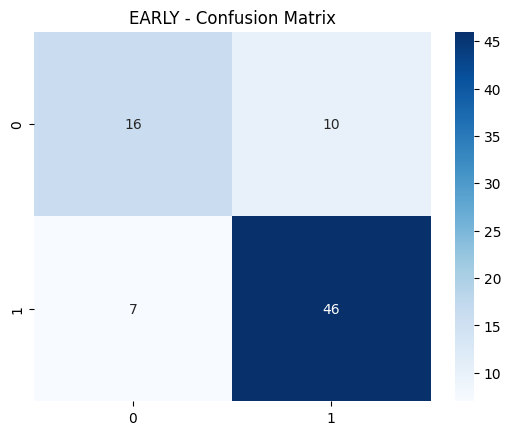

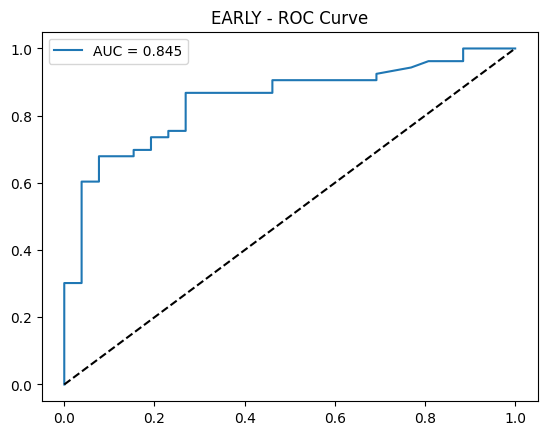


===== MID MODEL =====
Accuracy: 0.7722
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        26
           1       0.83      0.83      0.83        53

    accuracy                           0.77        79
   macro avg       0.74      0.74      0.74        79
weighted avg       0.77      0.77      0.77        79



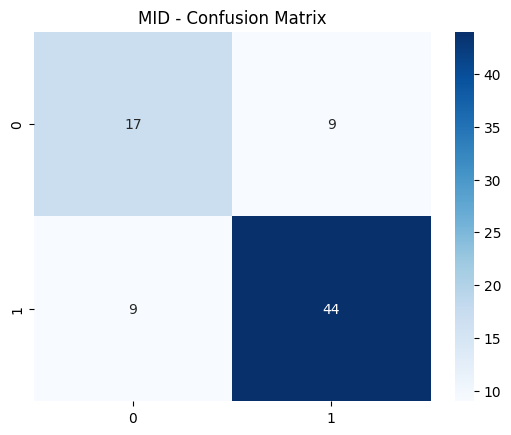

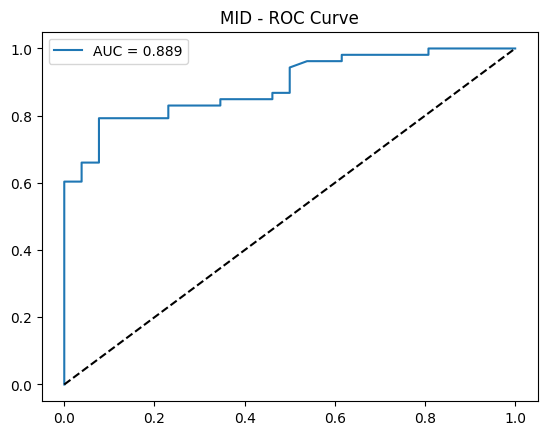


===== LATE MODEL =====
Accuracy: 0.8734
              precision    recall  f1-score   support

           0       0.77      0.88      0.82        26
           1       0.94      0.87      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.88      0.86        79
weighted avg       0.88      0.87      0.88        79



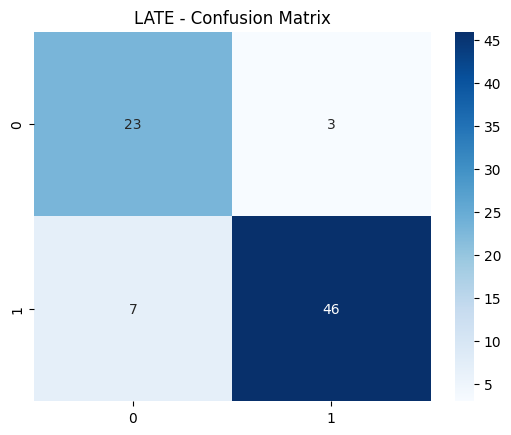

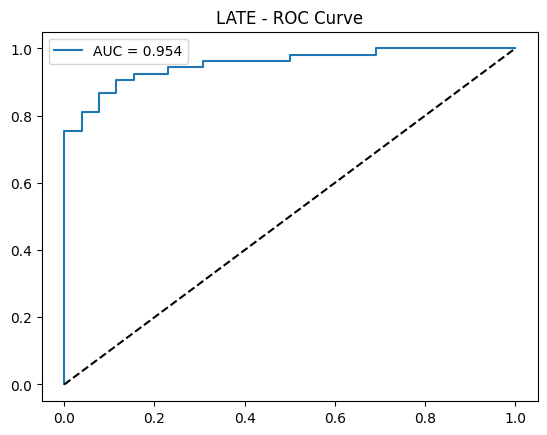

In [ ]:
#Evaluate models
evaluate("EARLY", cal_early, X_test_e, y_test)
evaluate("MID",   cal_mid,   X_test_m, y_test)
evaluate("LATE",  cal_late,  X_test_l, y_test)

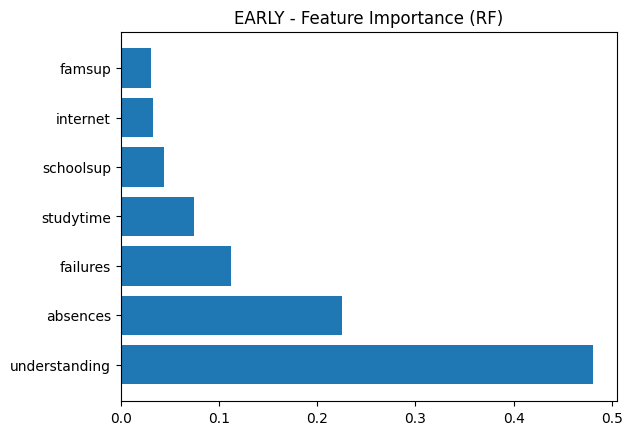

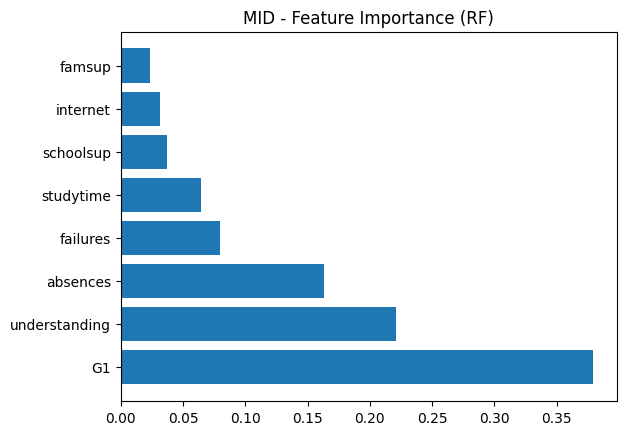

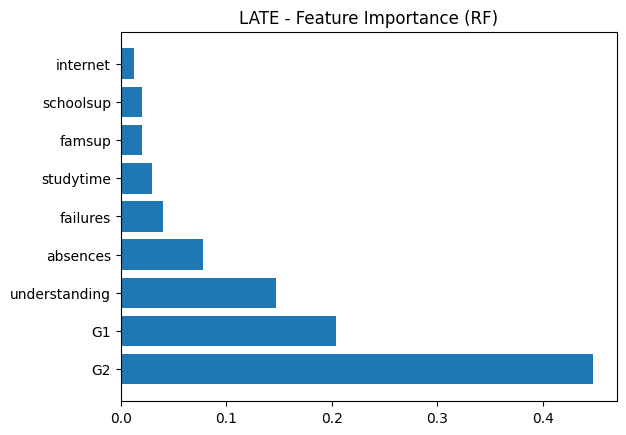

In [ ]:
#Feature importance plots
# Feature importance is taken from the RandomForest inside the ensemble (not calibrated model)
def plot_importance(name, rf_model, features):
    imps = rf_model.feature_importances_
    idx = np.argsort(imps)[::-1]

    plt.barh(np.array(features)[idx], imps[idx])
    plt.title(f"{name} - Feature Importance (RF)")
    plt.show()

# Access the fitted RandomForest estimators from the ensembles
plot_importance("EARLY", early_ens.estimators_[0], early_features)
plot_importance("MID",   mid_ens.estimators_[0],   mid_features)
plot_importance("LATE",  late_ens.estimators_[0],  late_features)

In [ ]:
#Export models for Streamlit
joblib.dump(cal_early, "early_model.pkl")
joblib.dump(cal_mid,   "mid_model.pkl")
joblib.dump(cal_late,  "late_model.pkl")

print("\nModels saved: early_model.pkl, mid_model.pkl, late_model.pkl")


Models saved: early_model.pkl, mid_model.pkl, late_model.pkl
